# ML Credit Card Fraud Detection System
### Jean Fernandes (JEF237@pitt.edu)



## Dataset Summary

This dataset contains European credit card transactions from September 2013, collected over a two-day period. It includes 284,807 transactions, of which 492 are fraudulent, meaning fraud cases represent only 0.172% of the dataset.

Because the dataset is highly imbalanced, standard accuracy is not a useful evaluation metric. Area Under the Precision-Recall Curve (AUPRC) is recommended instead, as it better reflects performance on the minority fraud class.

Most features are anonymized numerical variables produced through PCA transformation. Features `V1` through `V28` are principal components, while `Time` and `Amount` are the only non-PCA features. `Time` records the seconds elapsed since the first transaction, `Amount` records the transaction value, and `Class` is the target variable, where `1` indicates fraud and `0` indicates a legitimate transaction.


## Business Problem

Credit card fraud creates financial losses for banks, payment processors, merchants, and customers. The goal of this project is to build a machine learning model that can classify transactions as fraudulent or legitimate using anonymized transaction features. Because fraudulent transactions are extremely rare, the model should prioritize detecting fraud cases while keeping false alarms low enough that legitimate cardholders are not unnecessarily blocked or inconvenienced.

## Libraries & load data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score
)

pd.set_option("display.float_format", "{:,.2f}".format)

pd.set_option("display.max_columns", None)

def show(msg, obj=None):
    print("\n======== " + msg + " ========")
    if obj is not None:
        # Use IPython.display for nicer DataFrame/Series rendering
        if isinstance(obj, (pd.DataFrame, pd.Series)):
            display(obj)
        else:
            print(obj)
    # always leave a blank line under the printed/displayed object
    print()

In [ ]:
import kagglehub
import pandas as pd
from pathlib import Path

# Download the latest version
dataset_path = Path(
    kagglehub.dataset_download("mlg-ulb/creditcardfraud")
)

csv_path = dataset_path / "creditcard.csv"

print("Dataset folder:", dataset_path)
print("CSV file:", csv_path)

df = pd.read_csv(csv_path)

Dataset folder: C:\Users\Jean Fernandes\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
CSV file: C:\Users\Jean Fernandes\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,-0.55,-0.62,-0.99,-0.31,1.47,-0.47,0.21,0.03,0.40,0.25,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,1.61,1.07,0.49,-0.14,0.64,0.46,-0.11,-0.18,-0.15,-0.07,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,0.62,0.07,0.72,-0.17,2.35,-2.89,1.11,-0.12,-2.26,0.52,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,-0.23,0.18,0.51,-0.29,-0.63,-1.06,-0.68,1.97,-1.23,-0.21,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,-0.82,0.54,1.35,-1.12,0.18,-0.45,-0.24,-0.04,0.80,0.41,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


## Dataset Overview

In [6]:
show("DataFrame shape", df.shape)


======== DataFrame shape ========
(284807, 31)



In [21]:
print("======== DataFrame Info ========")
df.info()

======== DataFrame Info ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 

In [7]:
show("First 5 rows of the dataset", df.head())


======== First 5 rows of the dataset ========


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,-0.55,-0.62,-0.99,-0.31,1.47,-0.47,0.21,0.03,0.40,0.25,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,1.61,1.07,0.49,-0.14,0.64,0.46,-0.11,-0.18,-0.15,-0.07,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,0.62,0.07,0.72,-0.17,2.35,-2.89,1.11,-0.12,-2.26,0.52,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,-0.23,0.18,0.51,-0.29,-0.63,-1.06,-0.68,1.97,-1.23,-0.21,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,-0.82,0.54,1.35,-1.12,0.18,-0.45,-0.24,-0.04,0.80,0.41,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [ ]:
show("Stats", df.describe())


======== Stats ========


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,"284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00"
mean,"94,813.86",0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,"47,488.15",1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,1.09,1.02,1.00,1.00,0.96,0.92,0.88,0.85,0.84,0.81,0.77,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,-24.59,-4.80,-18.68,-5.79,-19.21,-4.50,-14.13,-25.16,-9.50,-7.21,-54.50,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,"54,201.50",-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,-0.54,-0.76,-0.41,-0.65,-0.43,-0.58,-0.47,-0.48,-0.50,-0.46,-0.21,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,"84,692.00",0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,-0.09,-0.03,0.14,-0.01,0.05,0.05,0.07,-0.07,-0.00,0.00,-0.06,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,"139,320.50",1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,0.45,0.74,0.62,0.66,0.49,0.65,0.52,0.40,0.50,0.46,0.13,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,"172,792.00",2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,23.75,12.02,7.85,7.13,10.53,8.88,17.32,9.25,5.04,5.59,39.42,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,"25,691.16",1.00


## Feature Engineering & Preprocessing

In [9]:
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

In [10]:
print("X shape:", X.shape)  # (284807, 30)
print("y shape:", y.shape)  # (284807,)
print(y.value_counts())

X shape: (284807, 30)
y shape: (284807,)
Class
0    284315
1       492
Name: count, dtype: int64


In [17]:
print("Features:", X.shape[1])

Features: 30


## Split

In [18]:
# Split first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Scale `Time` and `Amount`

In [19]:
scaler = RobustScaler()
cols_to_scale = ["Time", "Amount"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [24]:
print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

print(f"\nTraining set fraud rate: {y_train.mean():.2%}")
print(f"Test set fraud rate: {y_test.mean():.2%}")

Training set size: (227845, 30)
Test set size: (56962, 30)

Training set fraud rate: 0.17%
Test set fraud rate: 0.17%


In [20]:
print("Scaling completed using RobustScaler")
print("\nScaled data statistics:")
print(X_train_scaled.describe())

Scaling completed using RobustScaler

Scaled data statistics:
            Time         V1         V2         V3         V4         V5  \
count 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00   
mean        0.12       0.00      -0.00      -0.00      -0.00       0.00   
std         0.56       1.96       1.65       1.52       1.42       1.38   
min        -1.00     -56.41     -72.72     -48.33      -5.68    -113.74   
25%        -0.36      -0.92      -0.60      -0.89      -0.85      -0.69   
50%         0.00       0.02       0.06       0.18      -0.02      -0.05   
75%         0.64       1.32       0.80       1.03       0.74       0.61   
max         1.03       2.45      22.06       9.38      16.88      34.80   

              V6         V7         V8         V9        V10        V11  \
count 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00   
mean       -0.00       0.00      -0.00       0.00      -0.00      -0.00   
std         1.33       1.24       1.1

## Model Building & Training

In [25]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    roc_auc_score,
)

fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        random_state=42,
        subsample=0.8,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=fraud_ratio,
        eval_metric="logloss",
        n_jobs=-1,
    ),
}

results = {}

for name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"Training {name}...")
    print("=" * 60)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        "model": model,
        "accuracy": accuracy,
        "auprc": auprc,
        "roc_auc": roc_auc,
        "f1": f1,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
    }

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"AUPRC:    {auprc:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Training Logistic Regression...

Accuracy: 0.9755
AUPRC:    0.7175
ROC-AUC:  0.9720
F1-Score: 0.1142

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Training Random Forest...

Accuracy: 0.9995
AUPRC:    0.8528
ROC-AUC:  0.9565
F1-Score: 0.8432

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Training Gradient Boosting...

Accuracy: 0.9991
AUPRC:    0.5998
ROC-AUC:  0.8573
F1-Score: 0.7347


## Model Comparison & Visualization

In [27]:
from sklearn.metrics import precision_score, recall_score

comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "AUPRC": [
        results[m]["auprc"]
        for m in results
    ],
    "Fraud Precision": [
        precision_score(
            y_test,
            results[m]["y_pred"],
            zero_division=0,
        )
        for m in results
    ],
    "Fraud Recall": [
        recall_score(
            y_test,
            results[m]["y_pred"],
            zero_division=0,
        )
        for m in results
    ],
    "F1-Score": [
        results[m]["f1"]
        for m in results
    ],
})

comparison_df = comparison_df.sort_values(
    "AUPRC",
    ascending=False,
).reset_index(drop=True)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(
    comparison_df.style.format({
        "AUPRC": "{:.4f}",
        "Fraud Precision": "{:.4f}",
        "Fraud Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
    })
)


MODEL COMPARISON


,Model,AUPRC,Fraud Precision,Fraud Recall,F1-Score
0,XGBoost,0.8742,0.8542,0.8367,0.8454
1,Random Forest,0.8528,0.8966,0.7959,0.8432
2,Logistic Regression,0.7175,0.0609,0.9184,0.1142
3,Gradient Boosting,0.5998,0.7347,0.7347,0.7347


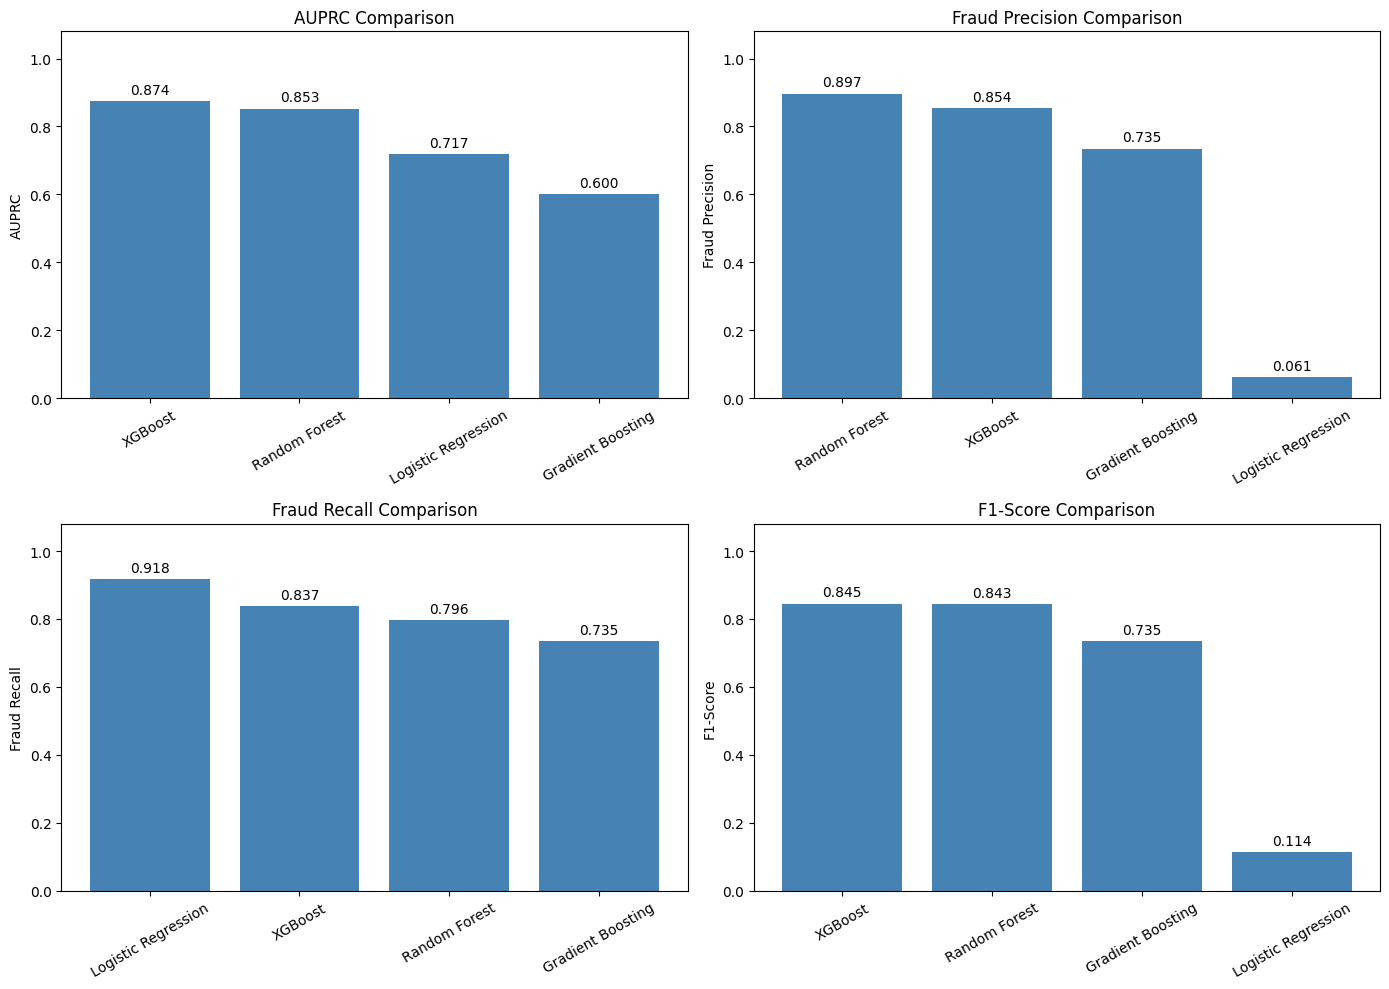

In [28]:
metrics = [
    "AUPRC",
    "Fraud Precision",
    "Fraud Recall",
    "F1-Score",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sorted_data = comparison_df.sort_values(
        metric,
        ascending=False,
    )

    bars = ax.bar(
        sorted_data["Model"],
        sorted_data[metric],
        color="steelblue",
    )

    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.08)
    ax.tick_params(axis="x", rotation=30)

    ax.bar_label(
        bars,
        labels=[f"{value:.3f}" for value in sorted_data[metric]],
        padding=3,
    )

plt.tight_layout()
plt.show()

## Confusion matrices

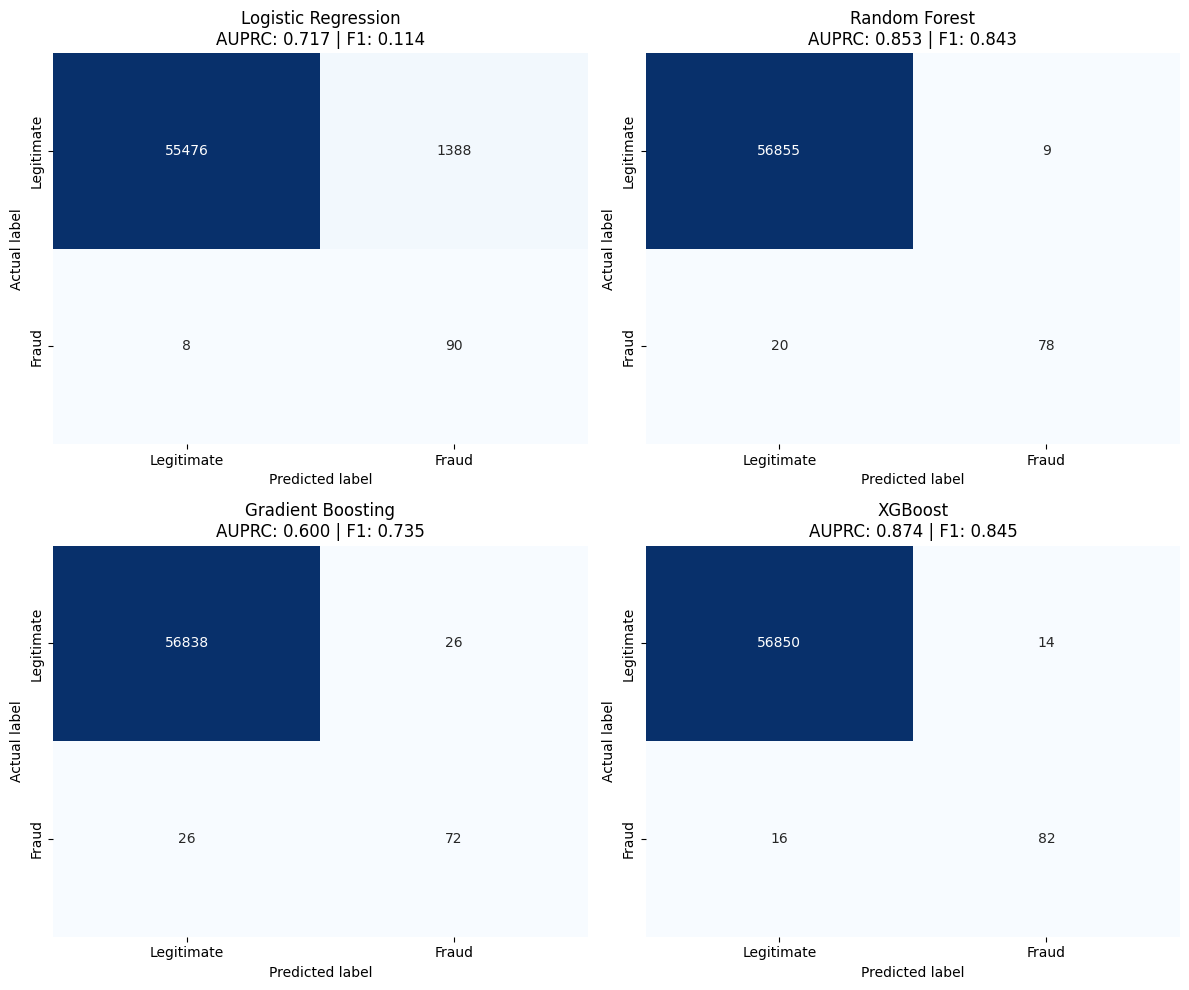

In [29]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]

    cm = confusion_matrix(y_test, result["y_pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"],
    )

    ax.set_title(
        f"{name}\n"
        f'AUPRC: {result["auprc"]:.3f} | '
        f'F1: {result["f1"]:.3f}'
    )
    ax.set_ylabel("Actual label")
    ax.set_xlabel("Predicted label")

plt.tight_layout()
plt.show()

## Feature Importance Analysis for XGBoost

Feature importance measures how much each input feature contributed to the XGBoost model's decisions. Higher values indicate that a feature provided more useful information when constructing decision trees.

In [30]:
# Retrieve the trained XGBoost model
xgb_model = results["XGBoost"]["model"]

# Extract feature importance
feature_importance_df = (
    pd.DataFrame({
        "Feature": X_train_scaled.columns,
        "Importance": xgb_model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df["Cumulative Importance"] = (
    feature_importance_df["Importance"].cumsum()
)

display(feature_importance_df.head(15))

,Feature,Importance,Cumulative Importance
0,V14,0.34,0.34
1,V10,0.14,0.48
2,V4,0.08,0.56
3,V12,0.06,0.62
4,V8,0.03,0.65
5,V20,0.03,0.68
6,V17,0.03,0.70
7,Amount,0.02,0.73
8,V26,0.02,0.75
9,V13,0.02,0.77


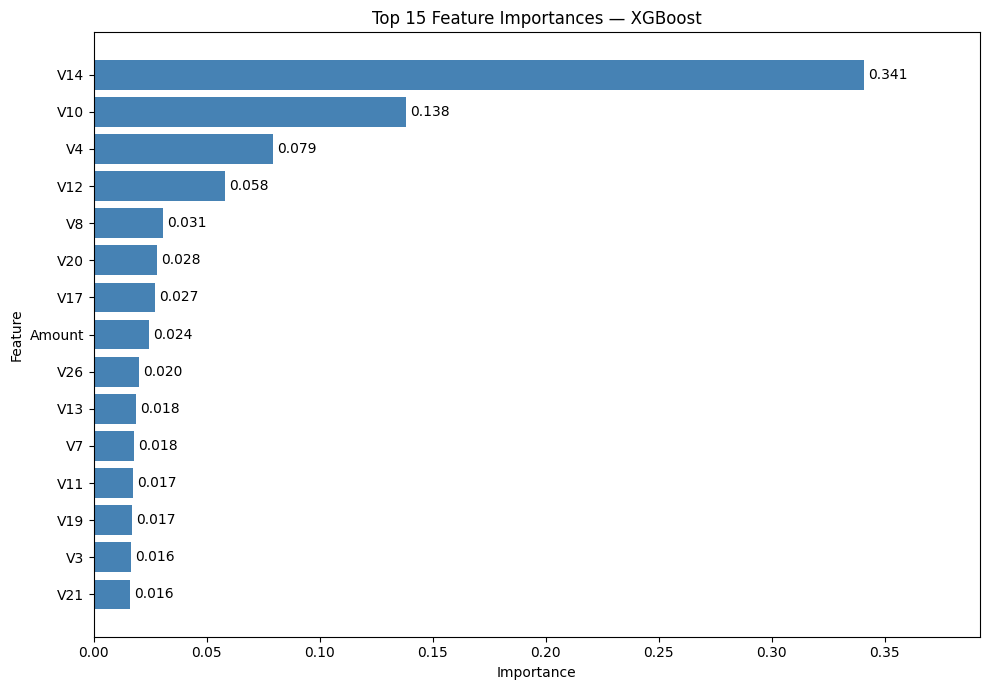

In [31]:
top_n = 15

top_features = (
    feature_importance_df
    .head(top_n)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="steelblue",
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.3f}"
        for value in top_features["Importance"]
    ],
    padding=3,
)

plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.xlim(
    0,
    top_features["Importance"].max() * 1.15,
)
plt.tight_layout()
plt.show()

The XGBoost feature-importance analysis shows which variables contributed most strongly to the model's predictions. Because features V1–V28 were anonymized through PCA, their business meaning cannot be interpreted directly. Importance also does not indicate whether higher values increase or decrease fraud risk, and it should not be interpreted as evidence of causation. SHAP analysis would be needed to examine the direction and transaction-level effects of each feature.